# Prewitt

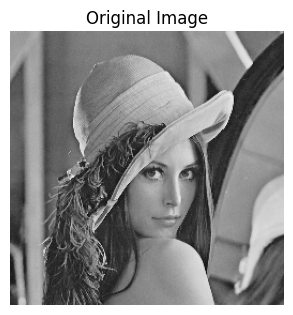

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os


image_path = 'DIPImage/lenna.png'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

In [127]:
prewitt_horizontal = np.array([[-1, -1, -1],
                               [ 0,  0,  0],
                               [ 1,  1,  1]])

prewitt_vertical = np.array([[-1,  0,  1],
                             [-1,  0,  1],
                             [-1,  0,  1]])

print("Prewitt Horizontal Kernel:")
print(prewitt_horizontal)
print("\nPrewitt Vertical Kernel:")
print(prewitt_vertical)

Prewitt Horizontal Kernel:
[[-1 -1 -1]
 [ 0  0  0]
 [ 1  1  1]]

Prewitt Vertical Kernel:
[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]


In [ ]:

def convolution(image, kernel):
 
    img_height, img_width = image.shape
    kernel_height, kernel_width = kernel.shape

    pad_h = kernel_height // 2
    pad_w = kernel_width // 2
    
    padded_image = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    

    output = np.zeros_like(image, dtype=np.float32)
    
    for i in range(img_height):
        for j in range(img_width):
            roi = padded_image[i:i+kernel_height, j:j+kernel_width]
            output[i, j] = np.sum(roi * kernel)
    
    return output


In [129]:

prewitt_h = convolution(img.astype(np.float32), prewitt_horizontal)
prewitt_v = convolution(img.astype(np.float32), prewitt_vertical)

In [ ]:
def normalize_image(image):
    image_abs = np.abs(image)
    if image_abs.max() > 0:
        normalized = (image_abs / image_abs.max()) * 255
    else:
        normalized = image_abs
    
    return normalized.astype(np.uint8)


prewitt_h_norm = normalize_image(prewitt_h)
prewitt_v_norm = normalize_image(prewitt_v)

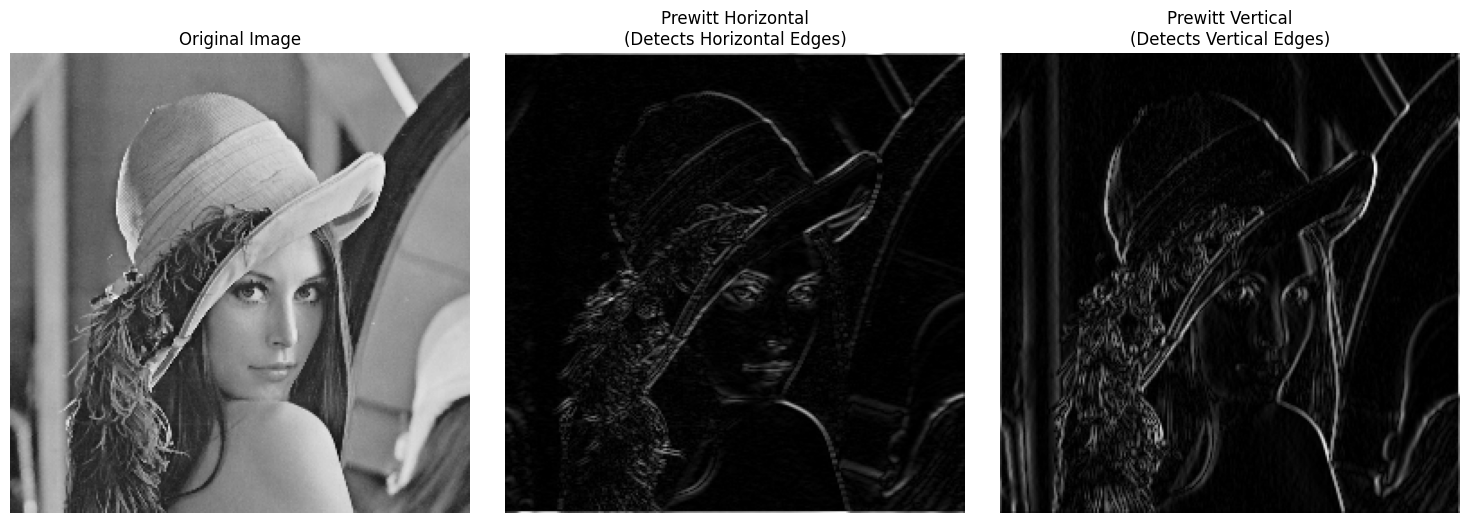

In [131]:
plt.figure(figsize=(15, 10))
# Original image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Horizontal Prewitt
plt.subplot(2, 3, 2)
plt.imshow(prewitt_h_norm, cmap='gray')
plt.title('Prewitt Horizontal\n(Detects Horizontal Edges)')
plt.axis('off')

# Vertical Prewitt
plt.subplot(2, 3, 3)
plt.imshow(prewitt_v_norm, cmap='gray')
plt.title('Prewitt Vertical\n(Detects Vertical Edges)')
plt.axis('off')

plt.tight_layout()
plt.show()

# Sobel

In [ ]:
sobel_horizontal = np.array([[-1, -2, -1],
                               [ 0,  0,  0],
                               [ 1,  2,  1]])

sobel_vertical = np.array([[-1,  0,  1],
                             [-2,  0,  2],
                             [-1,  0,  1]])

print("Sobel Horizontal Kernel:")
print(sobel_horizontal)
print("\Sobel Vertical Kernel:")
print(sobel_vertical)

Sobel Horizontal Kernel:
[[-1 -2 -1]
 [ 0  0  0]
 [ 1  2  1]]
\Sobel Vertical Kernel:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]


In [133]:
sobel_h = convolution(img.astype(np.float32), sobel_horizontal)
sobel_v = convolution(img.astype(np.float32), sobel_vertical)


sobel_h_norm = normalize_image(sobel_h)
sobel_v_norm = normalize_image(sobel_v)

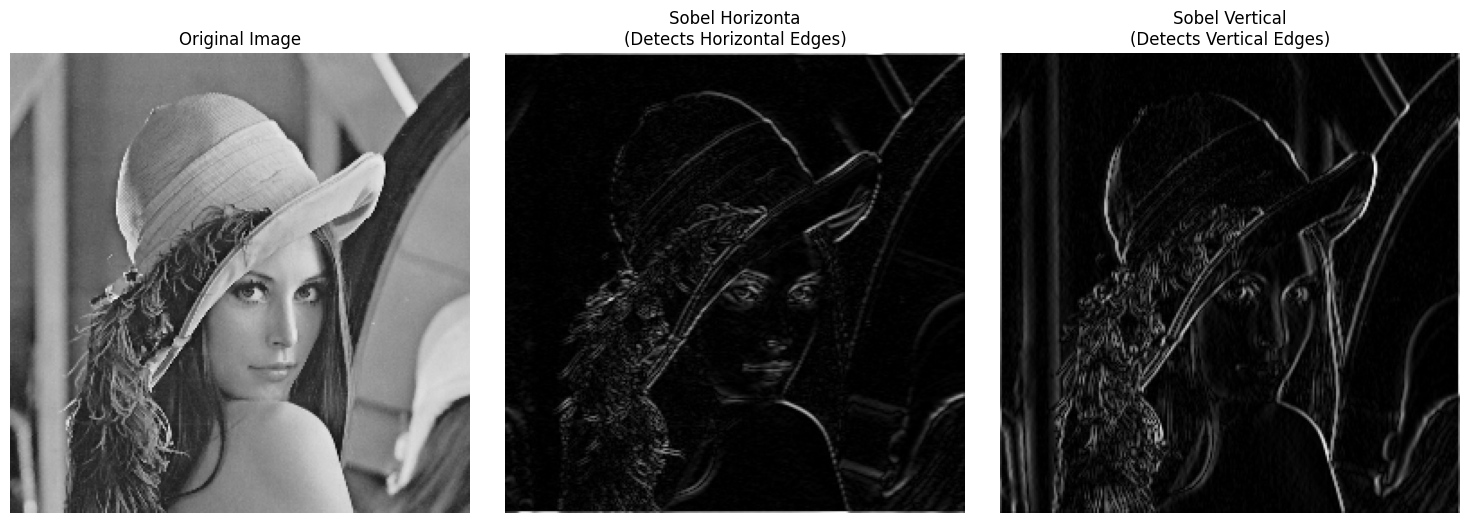

In [134]:
plt.figure(figsize=(15, 10))
# Original image
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Horizontal Prewitt
plt.subplot(2, 3, 2)
plt.imshow(sobel_h_norm, cmap='gray')
plt.title('Sobel Horizonta\n(Detects Horizontal Edges)')
plt.axis('off')

# Vertical Prewitt
plt.subplot(2, 3, 3)
plt.imshow(sobel_v_norm, cmap='gray')
plt.title('Sobel Vertical\n(Detects Vertical Edges)')
plt.axis('off')

plt.tight_layout()
plt.show()



# Canny Edge

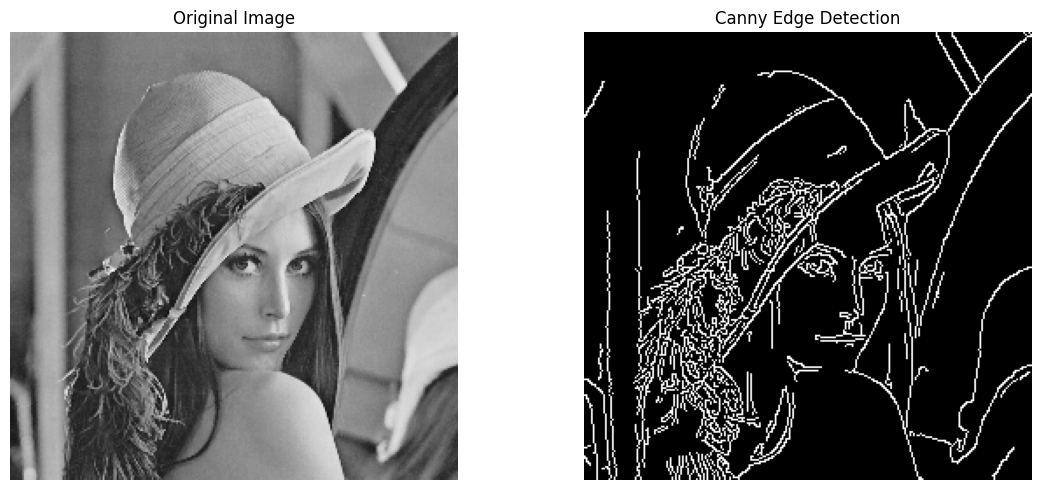

In [ ]:
canny_edges = cv2.Canny(img, 100, 200)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(canny_edges, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.tight_layout()
plt.show()

